In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../databases/word_dimensions_canon_cardinality.csv")

In [3]:
df.groupby("length")["dimensionZDense"].mean()

length
1    -1.000000
2    -1.000000
3     0.000000
4    -0.666667
5     0.000000
6     0.181818
7     0.000000
8    -0.152866
9    -0.071642
10   -0.078807
11   -0.033276
12   -0.099520
13    0.015378
14   -0.037411
15    0.052634
16    0.013124
Name: dimensionZDense, dtype: float64

In [4]:
df.groupby("length").size()

length
1          1
2          3
3          3
4          9
5         11
6         33
7         55
8        157
9        335
10       939
11      2314
12      6461
13     17102
14     47981
15    131777
16    371619
dtype: int64

In [5]:
df[df["dimensionZDense"] == 2]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
4,3,aaa,2,2,[x + 1],-1,-1
7,4,aaaa,2,2,[x],-1,-1
16,5,aaaaa,2,2,[x^2 + x - 1],-1,-1
27,6,aaaaaa,2,2,[x^2 - 1],-1,-1
41,6,aabaaB,2,2,[x],-1,-1
...,...,...,...,...,...,...,...
578793,16,abAbAbABaBabABaB,2,2,[x*y - z],-1,-1
578796,16,abAbABabABaBabAB,2,2,[x^2*y^2*z - x^3*y - x*y^3 - 2*x*y*z^2 + x^2*z...,-1,-1
578797,16,abAbABaBabAbABaB,2,2,[x*y - z],-1,-1
578798,16,abABabABabABabAB,2,2,[x*y*z - x^2 - y^2 - z^2 + 2],-1,-1


In [6]:
df[(df["length"] == 8) & (df["dimensionZDense"] == 2)]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
115,8,aaaaaaaa,2,2,[x^3 - 2*x],-1,-1
145,8,aaabaaaB,2,2,[x^2 - 1],-1,-1
172,8,aaabAAAB,2,2,[x^2 - 1],-1,-1
199,8,aababbab,2,2,[z],-1,-1
219,8,aabbaaBB,2,2,"[x^5 - 4*x^3*z^2 + 4*x*z^4, x^4*y - 4*x^3*z - ...",-1,-1
226,8,aabbAABB,2,2,[x*y],-1,-1
249,8,aaBaBBaB,2,2,[x*y - z],-1,-1
253,8,abababab,2,2,[z],-1,-1
261,8,ababABAB,2,2,[z^2],-1,-1
269,8,abAbABaB,2,2,[x*y - z],-1,-1


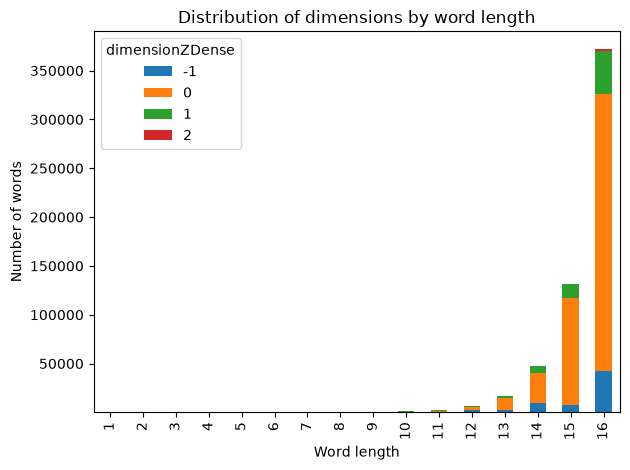

In [7]:
counts = df.groupby(["length", "dimensionZDense"]).size().unstack(fill_value=0)

counts.plot(kind="bar", stacked=True)

plt.xlabel("Word length")
plt.ylabel("Number of words")
plt.title("Distribution of dimensions by word length")
plt.tight_layout()
plt.show()

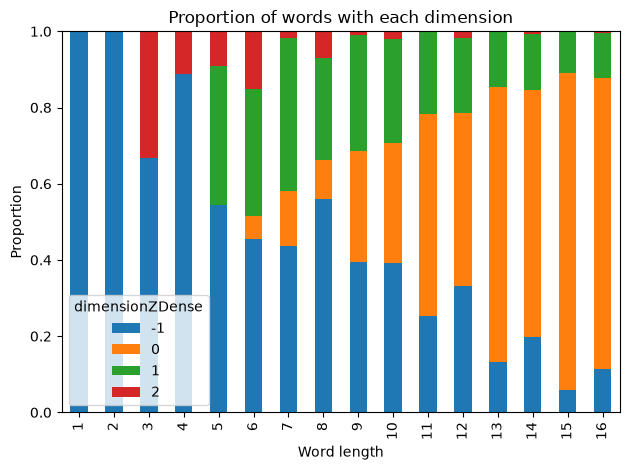

In [8]:
props = counts.div(counts.sum(axis=1), axis=0)

props.plot(kind="bar", stacked=True)

plt.ylabel("Proportion")
plt.xlabel("Word length")
plt.title("Proportion of words with each dimension")
plt.tight_layout()
plt.show()

In [9]:
dim2 = df[df['dimensionZDense'] == 2]
dim2[dim2['length'] == 7]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
60,7,aaaaaaa,2,2,[x^3 + x^2 - 2*x - 1],-1,-1


In [38]:
canon_df = pd.read_csv("../databases/word_dimensions_nogb.csv")

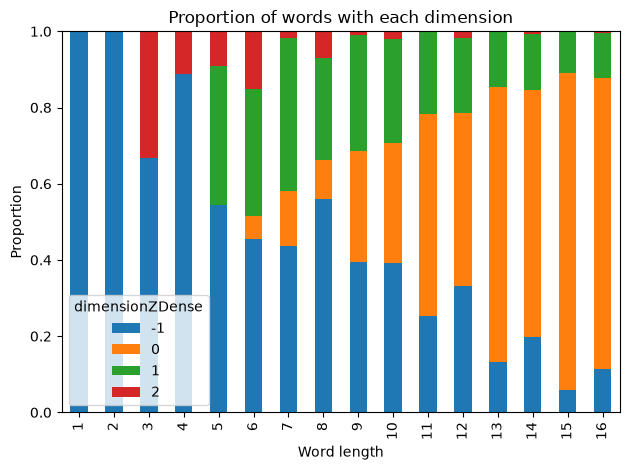

In [39]:
can_counts = canon_df.groupby(["length", "dimensionZDense"]).size().unstack(fill_value=0)
can_props = can_counts.div(can_counts.sum(axis=1), axis=0)

can_props.plot(kind="bar", stacked=True)

plt.ylabel("Proportion")
plt.xlabel("Word length")
plt.title("Proportion of words with each dimension")
plt.tight_layout()
plt.show()

In [12]:
cdim2 = canon_df[canon_df['dimensionZDense'] == 2]
cdim2[cdim2['length']== 13]

,length,word,dimension,dimensionZDense,basis
17711,13,aaaaaaaaaaaaa,2,2,[x^6 + x^5 - 5*x^4 - 4*x^3 + 6*x^2 + 3*x - 1]
18201,13,aaaaaabbaaaBB,2,2,"[x^5 + 2*x^4 - 2*x^3 - 5*x^2 - x + 1, x^4*z + ..."
18299,13,aaaaaabbAAABB,2,2,[x^3*z^2 - 3/2*x^2*y^2 + 2*x^2*z^2 - 2*x^3 - 1...
18686,13,aaaaaaBBaaabb,2,2,"[x^5 + 2*x^4 - 2*x^3 - 5*x^2 - x + 1, x^4*z + ..."
18742,13,aaaaaaBBAAAbb,2,2,[x^3*z^2 + 5/2*x^2*y*z + 2*x^2*z^2 - 3/2*x^3 +...
26837,13,aaabaaabaaaBB,2,2,[x*y^2*z^2 + y^2*z^2 - 1/2*x*y^2 - x*z^2 - 1/2...
26925,13,aaabaaabAAABB,2,2,[x^3*z^2 - 2/5*x^2*y^2 + 23/10*x^2*z^2 - 11/10...
27034,13,aaabaaaBBAAAb,2,2,[x*y^2*z^2 + y^2*z^2 - 2*x*z^2 - 1/2*x^2 - 2*z...
27056,13,aaabaabaaaBaB,2,2,[x*y*z^4 - x*z^5 + y*z^4 - z^5 - 9/2*x*y^2*z +...
27317,13,aaabaabAAABaB,2,2,[x*y*z^4 - 1/144*x^4*z + y*z^4 + 1/2*x^3*y + 1...


In [13]:
c_df = pd.read_csv("../databases/word_dimensions_canon_cardinality.csv")

In [14]:
c_df[(c_df['dimensionZDense'] == 2) & (c_df['length']%2 == 1)]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
4,3,aaa,2,2,[x + 1],-1,-1
16,5,aaaaa,2,2,[x^2 + x - 1],-1,-1
60,7,aaaaaaa,2,2,[x^3 + x^2 - 2*x - 1],-1,-1
272,9,aaaaaaaaa,2,2,[x^4 + x^3 - 3*x^2 - 2*x + 1],-1,-1
457,9,aabaabaab,2,2,"[x*z^3 - y*z^2 - 1/2*x*z + z^2 + 1/2*y - 1/2, ...",-1,-1
...,...,...,...,...,...,...,...
199075,15,aabAbaabAbaabAb,2,2,[x^3*y*z^3 - x^4*z^2 - 10/9*x^2*y^2*z^2 - 8/9*...,-1,-1
203720,15,aabABaabABaabAB,2,2,[x^4*y*z - x^5 - x^3*y^2 + 2*x^3*y*z - x^3*z^2...,-1,-1
205181,15,aaBaaBaaBaaBaaB,2,2,[x^4*y^2*z^3 - 2*x^3*y*z^4 - 1/4*x^5*y^2 - x^4...,-1,-1
206356,15,aaBaBaaBaBaaBaB,2,2,[x^5*y^2 - 2*x^4*y*z - 3*x^3*y^2 + x^3*z^2 + 5...,-1,-1


In [15]:
from power import is_power_or_power_conjugate_product
dim2 = c_df[c_df['dimensionZDense'] == 2].copy()
dim2['power_type'] = dim2['word'].apply(is_power_or_power_conjugate_product)
dim2

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality,power_type
4,3,aaa,2,2,[x + 1],-1,-1,"(True, (power, (a, a, a), (a,), 3))"
7,4,aaaa,2,2,[x],-1,-1,"(True, (power, (a, a, a, a), (a,), 4))"
16,5,aaaaa,2,2,[x^2 + x - 1],-1,-1,"(True, (power, (a, a, a, a, a), (a,), 5))"
27,6,aaaaaa,2,2,[x^2 - 1],-1,-1,"(True, (power, (a, a, a, a, a, a), (a,), 6))"
41,6,aabaaB,2,2,[x],-1,-1,"(True, (power_conjugate, (a, a, b, a, a, B), (..."
...,...,...,...,...,...,...,...,...
578793,16,abAbAbABaBabABaB,2,2,[x*y - z],-1,-1,"(False, None)"
578796,16,abAbABabABaBabAB,2,2,[x^2*y^2*z - x^3*y - x*y^3 - 2*x*y*z^2 + x^2*z...,-1,-1,"(False, None)"
578797,16,abAbABaBabAbABaB,2,2,[x*y - z],-1,-1,"(True, (power, (a, b, A, b, A, B, a, B, a, b, ..."
578798,16,abABabABabABabAB,2,2,[x*y*z - x^2 - y^2 - z^2 + 2],-1,-1,"(True, (power, (a, b, A, B, a, b, A, B, a, b, ..."


In [16]:
false_rows = dim2[~dim2['power_type'].apply(lambda x: x[0])]
words = false_rows[false_rows['length'] <= 16]['word'].tolist()
for w in words:
    print(w)

aabAAB
aaabAAAB
aabbAABB
ababABAB
abAbABaB
aaaaaabaaB
aaaaaabAAB
aaaabAAAAB
aaabbAAABB
aababAABAB
aabaBAAbAB
aabaBAABAb
aabAbAABaB
aaBabAAbAB
aaaaaabaaaB
aaaaaabAAAB
aaaaaabbaaBB
aaaaaabbAABB
aaaaabAAAAAB
aaaabaabaaBB
aaaabaabAABB
aaaabaaBBaab
aaaabaaBBAAb
aaaababaaBaB
aaaababAABaB
aaaabaBaabaB
aaaabaBAAbaB
aaaabbaaBaaB
aaaabbaaBAAB
aaaabbAAAABB
aaaabbAABaaB
aaaabbAABAAB
aaaabAbaaBAB
aaaabAbAABAB
aaaabAAbaaBB
aaaabAAbAABB
aaaabAABBAAb
aaaabABaabAB
aaaabABAAbAB
aaaaBaabbaaB
aaaaBaabbAAB
aaaaBAAbbAAB
aaabaaBabaaB
aaabaaBabAAB
aaabaaBaBaab
aaabaaBaBAAb
aaababAAABAB
aaabaBAAAbAB
aaabaBAAABAb
aaabbbAAABBB
aaabAbAAABaB
aaabAABabaaB
aaabAABabAAB
aaabAABaBAAb
aaaBaababaaB
aaaBaababAAB
aaaBabAAAbAB
aaaBAAbabAAB
aabaabaaBaaB
aabaabAABaaB
aabaabAABAAB
aabaaBAAbAAB
aababbAABABB
aababbAABBAB
aababbABAABB
aababAbABABB
aababABBABAb
aabaBBAAbbAB
aabaBBAABAbb
aabbaBAAbABB
aabbaBAABBAb
aabbAbAABaBB
aabbAbAABBaB
aabbAbABABaB
aabbAAbaBBAB
aabbAAbABBaB
aabbAABaBBAb
aabAbbAABaBB
aabAAbaaBAAB
aabAAbAABaaB
aa

In [17]:
cdim0 = c_df[c_df['dimensionZDense'] == 0]

In [18]:
cdim0['radical_cardinality'].describe()

count    442119.000000
mean         12.110079
std           6.437322
min           2.000000
25%           8.000000
50%          12.000000
75%          16.000000
max          48.000000
Name: radical_cardinality, dtype: float64

In [19]:
counts = cdim0["radical_cardinality"].value_counts().sort_index()
print(counts)

radical_cardinality
2     15617
4     55685
6     29064
8     66048
10    34441
12    66395
14    33235
16    50429
18    22950
20    28382
22    11979
24    13005
26     5165
28     4955
30     1756
32     1657
34      564
36      455
38      171
40      101
42       32
44       25
46        2
48        6
Name: count, dtype: int64


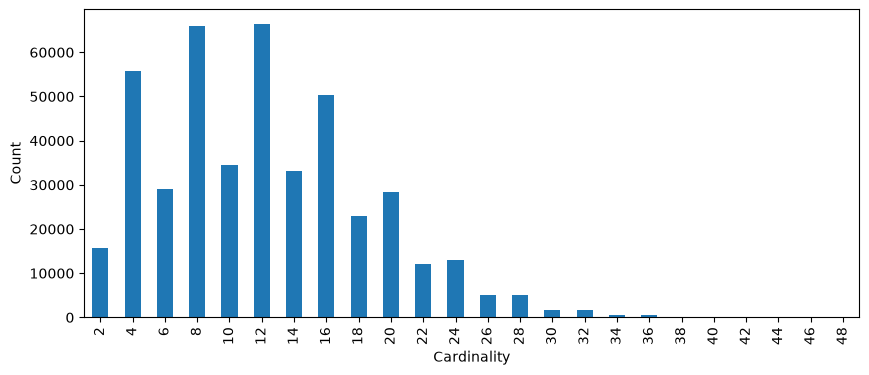

In [20]:
import matplotlib.pyplot as plt

counts.plot(kind="bar", figsize =(10,4))

plt.xlabel("Cardinality")
plt.ylabel("Count")
plt.show()

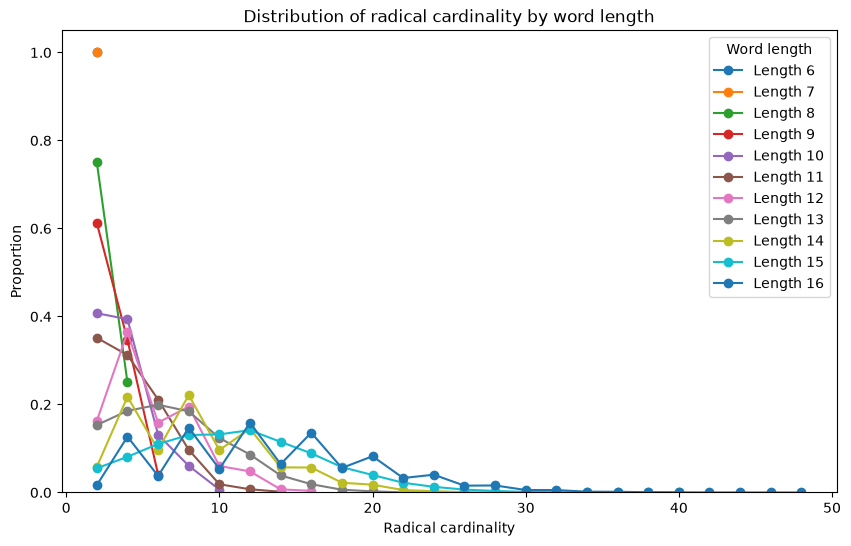

In [43]:
plt.figure(figsize=(10,6))

for length, group in cdim0.groupby("length"):
    props = (
        group["radical_cardinality"]
        .value_counts(normalize=True)
        .sort_index()
    )

    plt.plot(props.index, props.values,
             marker='o', label=f"Length {length}")

plt.xlabel("Radical cardinality")
plt.ylabel("Proportion")
plt.ylim(bottom=0)
plt.title("Distribution of radical cardinality by word length")
plt.legend(title="Word length")
plt.show()

In [21]:
cdim0[cdim0["cardinality"] != 2 * cdim0["radical_cardinality"]]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
859,10,aaababbaBB,1,0,"[y^4 - 2*x*y - 2*y^2 - 1, x*y^2 - y^3 + y*z + ...",8,2
945,10,aaabbaBBaB,1,0,"[x*y^2 - x*z - 2*y*z + y, y^3 - 2*x*z - 3*y*z ...",8,2
991,10,aaabbABBAB,1,0,[y^4 + 2/3*y^2*z - 2/3*z^3 - 2/15*x^2 + 2/15*x...,16,6
1008,10,aaabAbbABB,1,0,[x*y^3 + 2*z^3 - 7*x^2 + 2*x*y + 11*y^2 - 5*z^...,16,6
1296,10,aabaBBabAB,1,0,"[x*y*z - x*y - z^2 + 2*z - 1, x*z^2 - 2*x*z - ...",8,2
...,...,...,...,...,...,...,...
578377,16,ababABaBABaBabAB,1,0,"[x*y^3 - 5/4*y^2*z + 1/2*z^3 - 1/4*z, y^4 - 2*...",16,4
578496,16,abaBabaBAbABaBAB,1,0,"[x*y^3 + y^2*z + 11/2*z^3 - x*y - 2*z, y^4 + x...",16,4
578501,16,abaBabAbabAbaBAB,1,0,"[x*y^3 - 5*y^2*z + 3*z^3 + 5*x*y - 3*z, y^4 - ...",16,4
578508,16,abaBabAbabABAbaB,1,0,"[x*y^3 - 9/2*y^2*z + 3/2*z^3 + 4*x*y - 7/2*z, ...",16,4


In [22]:
c_df[c_df['dimensionZDense'] == 2]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
4,3,aaa,2,2,[x + 1],-1,-1
7,4,aaaa,2,2,[x],-1,-1
16,5,aaaaa,2,2,[x^2 + x - 1],-1,-1
27,6,aaaaaa,2,2,[x^2 - 1],-1,-1
41,6,aabaaB,2,2,[x],-1,-1
...,...,...,...,...,...,...,...
578793,16,abAbAbABaBabABaB,2,2,[x*y - z],-1,-1
578796,16,abAbABabABaBabAB,2,2,[x^2*y^2*z - x^3*y - x*y^3 - 2*x*y*z^2 + x^2*z...,-1,-1
578797,16,abAbABaBabAbABaB,2,2,[x*y - z],-1,-1
578798,16,abABabABabABabAB,2,2,[x*y*z - x^2 - y^2 - z^2 + 2],-1,-1


In [23]:
cdim0[cdim0["cardinality"] == 2 * cdim0["radical_cardinality"]]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
46,6,aabbAB,1,0,"[x^2 + z - 1, x*y + 1, y^2 - z - 1, x*z + x + ...",4,2
49,6,aabABB,1,0,"[y^2 - z - 2, z^2 + 2*z + 1, x + y]",4,2
79,7,aaabbAB,1,0,"[x^2 - y - 3, y^2 + 2*y + 1, z]",4,2
82,7,aaabABB,1,0,"[x^2 + y - 1, x*y + 2*x + z, y^2 + 2*y + 1, x*...",4,2
92,7,aababAB,1,0,"[y^2 + 2*y + 1, z^2 - y - 2, x + z]",4,2
...,...,...,...,...,...,...,...
578722,16,abaBAbaBaBAbaBAB,1,0,"[y^4 - y^2 + 1/4, x^2 - y^2, z]",8,4
578733,16,abaBAbAbAbaBAbAB,1,0,"[x*y*z - 12, x*z^2 + 4/3*y*z - 32/3*x, y*z^2 -...",8,4
578734,16,abaBAbAbAbAbaBAB,1,0,[x*y^3*z - 5*y^2*z^2 + 37/47*z^4 + 400/47*x*y*...,24,12
578739,16,abaBAbABabAbaBAB,2,0,"[x*y*z - 1/2*z^2 - 1/2, x*z^2 - 2*y*z + x, y*z...",8,4


In [24]:
cdim0['cardinality'].describe()

count    442119.000000
mean         24.921263
std          12.798137
min           4.000000
25%          16.000000
50%          24.000000
75%          32.000000
max          96.000000
Name: cardinality, dtype: float64

In [25]:
words = ["aaaaabAAAAAB", "aaaabbAAAABB", "aaababAAABAB", "aaabaBAAABAb", "aaabbbAAABBB", "aaabAbAAABaB", "aaaBabAAAbAB", "aabaabAABAAB", "aababbAABABB", "aabaBBAABAbb", "aabbabAABBAB", "aabbaBAABBAb", "aabbbbAABBBB", "aabbAbAABBaB", "aabAbbAABaBB", "aabAAbAABaaB", "aaBabbAAbABB", "aaBAbbAAbaBB", "abababABABAB", "ababbbABABBB", "ababAbABABaB", "abaBabABAbAB", "abbabbABBABB", "abbbabABBBAB", "abbbbbABBBBB", "abbbAbABBBaB", "abbAbbABBaBB", "abAbabABaBAB", "abAbbbABaBBB", "abAbAbABaBaB", "abABabABabAB"]
c_df[c_df['word'].isin(words)]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
4316,12,aaaaabAAAAAB,2,2,[x^4 - 3*x^2 + 1],-1,-1
5001,12,aaaabbAAAABB,2,2,"[x^5*y - 4*x^3*y + 4*x*y, x^3*y^2 - 2*x*y^2]",-1,-1
6016,12,aaababAAABAB,2,2,[x^2*z - z],-1,-1
6217,12,aaabaBAAABAb,2,2,[x^2*z - x*y - z],-1,-1
6675,12,aaabbbAAABBB,2,2,"[x^4*y^2 - x^4 - 2*x^2*y^2 + 2*x^2 + y^2 - 1, ...",-1,-1
7088,12,aaabAbAAABaB,2,2,[x^5*y - x^4*z - 3*x^3*y + 3*x^2*z + 2*x*y - 2...,-1,-1
7603,12,aaaBabAAAbAB,2,2,[x^3*y - x^2*z - 2*x*y + z],-1,-1
8065,12,aabaabAABAAB,2,2,[x^3*z^2 - 2*x^2*y*z + x*y^2],-1,-1
8434,12,aababbAABABB,2,2,[x*y*z - 1],-1,-1
9078,12,aabaBBAABAbb,2,2,[x*y*z - y^2 + 1],-1,-1


In [26]:
words14 = ["aaaaaabAAAAAAB", "aaaaabbAAAAABB", "aaaababAAAABAB", "aaaabaBAAAABAb", "aaaabbbAAAABBB", "aaaabAbAAAABaB", "aaaaBabAAAAbAB", "aaabaabAAABAAB", "aaabaaBAAABAAb", "aaababbAAABABB", "aaabaBBAAABAbb", "aaabbabAAABBAB", "aaabbaBAAABBAb", "aaabbbbAAABBBB", "aaabbAbAAABBaB", "aaabAbbAAABaBB", "aaabAAbAAABaaB", "aaaBaabAAAbAAB", "aaaBabbAAAbABB", "aaaBAbbAAAbaBB", "aabaabbAABAABB", "aabababAABABAB", "aababaBAABABAb", "aababbbAABABBB", "aababAbAABABaB", "aababABAABABab", "aabaBabAABAbAB", "aabaBaBAABAbAb", "aabaBAbAABAbaB", "aabaBBBAABAbbb", "aabbaabAABBAAB", "aabbabbAABBABB", "aabbaBBAABBAbb", "aabbbabAABBBAB", "aabbbaBAABBBAb", "aabbbbbAABBBBB", "aabbbAbAABBBaB", "aabbAbbAABBaBB", "aabbAAbAABBaaB", "aabAbabAABaBAB", "aabAbaBAABaBAb", "aabAbbbAABaBBB", "aabAbAbAABaBaB", "aabAAbbAABaaBB", "aabABabAABabAB", "aabABAbAABabaB", "aaBababAAbABAB", "aaBabbbAAbABBB", "aaBabAbAAbABaB", "aaBaBabAAbAbAB", "aaBAbabAAbaBAB", "aaBAbbbAAbaBBB", "aaBBabbAAbbABB", "abababbABABABB", "ababbabABABBAB", "ababbaBABABBAb", "ababbbbABABBBB", "ababbAbABABBaB", "ababAbbABABaBB", "abaBabbABAbABB", "abaBAbbABAbaBB", "abbabbbABBABBB", "abbabAbABBABaB", "abbaBabABBAbAB", "abbbabbABBBABB", "abbbbabABBBBAB", "abbbbbbABBBBBB", "abbbbAbABBBBaB", "abbbAbbABBBaBB", "abbAbabABBaBAB", "abbAbaBABBaBAb", "abbAbbbABBaBBB", "abbAbAbABBaBaB", "abbABabABBabAB", "abbABaBABBabAb", "abAbbbbABaBBBB", "abAbbAbABaBBaB", "abAbAbbABaBaBB"]
c_df[c_df['word'].isin(words14)]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
28750,14,aaaaaabAAAAAAB,2,2,[x^5 - 4*x^3 + 3*x],-1,-1
30832,14,aaaaabbAAAAABB,2,2,"[x^8*y - 6*x^6*y + 11*x^4*y - 6*x^2*y + y, x^4...",-1,-1
34207,14,aaaababAAAABAB,2,2,"[x^5*z - 3*x^3*z + 2*x*z, x^3*z^2 - 2*x*z^2]",-1,-1
34834,14,aaaabaBAAAABAb,2,2,[x^3*z - x^2*y - 2*x*z + y],-1,-1
36641,14,aaaabbbAAAABBB,2,2,[x^6*y^2 - x^6 - 4*x^4*y^2 + 4*x^4 + 4*x^2*y^2...,-1,-1
38038,14,aaaabAbAAAABaB,2,2,[x^8*y - x^7*z - 5*x^6*y + 5*x^5*z + 7*x^4*y -...,-1,-1
40024,14,aaaaBabAAAAbAB,2,2,[x^4*y - x^3*z - 3*x^2*y + 2*x*z + y],-1,-1
42470,14,aaabaabAAABAAB,2,2,[x^3*z - x^2*y - x*z + y],-1,-1
43085,14,aaabaaBAAABAAb,2,2,[x^3*z - x^2*y - x*z],-1,-1
45006,14,aaababbAAABABB,2,2,[x^2*y*z - y*z - x],-1,-1


In [27]:
inverse = {'a':'A', 'A':'a', 'b':'B', 'B':'b'}

def tilde_inverse(u):
    return ''.join(inverse[c] for c in u)

def is_u_tilde_u_inverse(word):
    if len(word) % 2:
        return False

    n = len(word) // 2
    u = word[:n]
    return word == u + tilde_inverse(u)

In [28]:
for word in words14:
    if not is_u_tilde_u_inverse(word):
        print(word)

In [29]:
from dim2 import uru
bad = []
mbad = []
for i in range(1, 9):
    for w in uru(2*i):
        row = c_df[c_df['word'] == w]
        if row.empty:
            mbad.append((w, "missing"))
        elif row['dimensionZDense'].iloc[0] != 2:
            bad.append((w, row["dimensionZDense"].iloc[0]))
        if w in words14:
            words14.remove(w)

if bad:
    print("Counterexamples:")
    for w, d in bad:
        print(f"{w}: dimensionZDense = {d}")
else:
    print('all w dim 2')
print(mbad)
print(words14)

aaaaaabAAAAAAB
aaaaabbAAAAABB
aaaababAAAABAB
aaaabaBAAAABAb
aaaabbbAAAABBB
aaaabAbAAAABaB
aaaaBabAAAAbAB
aaabaabAAABAAB
aaabaaBAAABAAb
aaababbAAABABB
aaabaBBAAABAbb
aaabbabAAABBAB
aaabbaBAAABBAb
aaabbAbAAABBaB
aaabAbbAAABaBB
aaabAAbAAABaaB
aaaBaabAAAbAAB
aaaBabbAAAbABB
aaaBAbbAAAbaBB
aabaabbAABAABB
aabababAABABAB
aababaBAABABAb
aababAbAABABaB
aababABAABABab
aabaBabAABAbAB
aabaBaBAABAbAb
aabaBAbAABAbaB
aabbaabAABBAAB
aabbAbbAABBaBB
aabAbabAABaBAB
aabAbaBAABaBAb
aabAbAbAABaBaB
aabAAbbAABaaBB
aabABabAABabAB
aabABAbAABabaB
aaBababAAbABAB
aaBabAbAAbABaB
aaBaBabAAbAbAB
aaBAbabAAbaBAB
Counterexamples:
abAB: dimensionZDense = -1
[]
['aaabbbbAAABBBB', 'aababbbAABABBB', 'aabaBBBAABAbbb', 'aabbabbAABBABB', 'aabbaBBAABBAbb', 'aabbbabAABBBAB', 'aabbbaBAABBBAb', 'aabbbbbAABBBBB', 'aabbbAbAABBBaB', 'aabbAAbAABBaaB', 'aabAbbbAABaBBB', 'aaBabbbAAbABBB', 'aaBAbbbAAbaBBB', 'aaBBabbAAbbABB', 'abababbABABABB', 'ababbabABABBAB', 'ababbaBABABBAb', 'ababbbbABABBBB', 'ababbAbABABBaB', 'ababAbbABABaBB', 'abaBab

In [30]:
len(c_df[(c_df["dimension"] == 2) & (c_df["dimensionZDense"] != 2)])

7583

In [31]:
def zero_word(word):
    acount = 0
    bcount = 0
    for letter in word:
        if letter == 'a':
            acount += 1
        elif letter == 'A':
            acount -= 1
        elif letter == 'b':
            bcount += 1
        else:
            bcount -=1
    return (acount, bcount) == (0,0)

In [32]:
len(c_df[
    (c_df["dimension"] == 2) &
    (c_df["dimensionZDense"] != 2) &
    (c_df["word"].apply(zero_word))
])

7583

In [33]:
c_df

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality
0,1,a,1,-1,[1],-1,-1
1,2,aa,1,-1,[1],-1,-1
2,2,ab,1,-1,[1],-1,-1
3,2,aB,1,-1,[1],-1,-1
4,3,aaa,2,2,[x + 1],-1,-1
...,...,...,...,...,...,...,...
578795,16,abAbABabABabABaB,2,-1,[1],-1,-1
578796,16,abAbABabABaBabAB,2,2,[x^2*y^2*z - x^3*y - x*y^3 - 2*x*y*z^2 + x^2*z...,-1,-1
578797,16,abAbABaBabAbABaB,2,2,[x*y - z],-1,-1
578798,16,abABabABabABabAB,2,2,[x*y*z - x^2 - y^2 - z^2 + 2],-1,-1


In [34]:
len(c_df[
    (c_df["dimension"] == 2) &
    (~(c_df["word"].apply(zero_word)))
])

1580

In [35]:
len(dim2[
    (~dim2["word"].apply(zero_word)) &
    (~dim2["power_type"].apply(lambda x: x[0])) &
    (dim2['dimensionZDense'] == 2)
])

1220

In [36]:
len(dim2[
    (~dim2["word"].apply(zero_word)) &
    (dim2['dimensionZDense'] == 2)
])

1580

In [37]:
dim2[
    (~dim2["word"].apply(zero_word)) &
    (~dim2["power_type"].apply(lambda x: x[0])) &
    (dim2['dimensionZDense'] == 2)
]

,length,word,dimension,dimensionZDense,gb basis,cardinality,radical_cardinality,power_type
621,10,aaaaaabaaB,2,2,[x],-1,-1,"(False, None)"
629,10,aaaaaabAAB,2,2,[x],-1,-1,"(False, None)"
1576,11,aaaaaabaaaB,2,2,"[x*z^2 + z^2 + 1/2*x + 1/2, x^2 + 2*x + 1, x*y...",-1,-1,"(False, None)"
1604,11,aaaaaabAAAB,2,2,"[x*z^2 + z^2 - 3/2*x - 3/2, x^2 + 2*x + 1, x*y...",-1,-1,"(False, None)"
3979,12,aaaaaabbaaBB,2,2,"[x^3 - 2*x, x*y]",-1,-1,"(False, None)"
...,...,...,...,...,...,...,...,...
577890,16,ababAbabaBababAB,2,2,[z],-1,-1,"(False, None)"
578662,16,abaBaBaBaBAbABaB,2,2,"[x^3*y - x^2*z - 3/2*x*y + 3/2*z, x^2*y^2 - 2*...",-1,-1,"(False, None)"
578686,16,abaBaBAbaBaBABaB,2,2,[x*y - z],-1,-1,"(False, None)"
578783,16,abAbAbAbAbAbABaB,2,2,[x*y - z],-1,-1,"(False, None)"
